### The purpose of this notebook to explore what cleaning techniques needed to be done. so I can build a proper cleaner script

In [169]:
import pandas as pd 
import numpy as np
import matplotlib.pyplot as plt
import yaml


In [170]:
with open('../config.yaml', 'r') as f:
    config = yaml.safe_load(f)

In [171]:
df = pd.read_csv(config['data_source']['file_paths']['raw_file'])
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 70534 entries, 0 to 70533
Data columns (total 44 columns):
 #   Column                       Non-Null Count  Dtype  
---  ------                       --------------  -----  
 0   title                        70532 non-null  object 
 1   city                         70534 non-null  object 
 2   district                     70534 non-null  object 
 3   area                         63943 non-null  object 
 4   neighborhood                 40712 non-null  object 
 5   property_type                70534 non-null  object 
 6   sale_or_rent                 70534 non-null  object 
 7   price                        70344 non-null  object 
 8   seller_name                  70534 non-null  object 
 9   area (mÂ²)                   0 non-null      float64
 10  property_subtype             70344 non-null  object 
 11  bedrooms                     70344 non-null  object 
 12  bathrooms                    70344 non-null  object 
 13  purpose         

C:\Users\marwa\AppData\Local\Temp\ipykernel_35600\2548498825.py:1: DtypeWarning: Columns (11,12,15,20,24,25,26,42,43) have mixed types. Specify dtype option on import or set low_memory=False.
  df = pd.read_csv(config['data_source']['file_paths']['raw_file'])


In [ ]:
null_titles = df[df['title'].isnull()]


In [172]:
pd.set_option('display.max_columns', None)

In [17]:
null_titles.head()

,title,city,district,area,neighborhood,property_type,sale_or_rent,price,seller_name,area (mÂ²),property_subtype,bedrooms,bathrooms,purpose,ownership,level,payment option,furnished,completion status,delivery term,delivery date,monthly installments,payment period (years),price type,deposit,insurance,rental frequency,electricity meter,water meter,covered parking,natural gas,security,pets allowed,balcony,private garden,pool,landline,maids room,built in kitchen appliances,elevator,central a/c & heating,listing_date,area (m²),compound
63142,NaN,Cairo,Mostakbal City,Aliva mostakbal city,NaN,villas,sale,"EGP 23,000,000",This ad is no longer available,NaN,iVilla,4,4,for sale,NaN,NaN,installment,NaN,ready,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,True,True,True,True,True,True,False,True,True,True,False,True,False,False,04-27-2026,310,NaN
66992,NaN,Cairo,Katameya,West Golf Compound,NaN,villas,sale,"EGP 75,000,000",Kemet Real Estate,NaN,Stand Alone Villa,10+,10+,for sale,resale,NaN,cash,yes,ready,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,False,False,False,False,False,False,False,False,False,False,False,False,False,False,04-30-2026,"2,500",NaN


In [19]:
price_type = df['price type'].value_counts()
price_type

price type
negotiable    1158
Name: count, dtype: int64

In [37]:
cols = df.columns
cols[9]

'area (mÂ²)'

In [173]:
x = df[df['compound'].notnull()]
x.head()

,title,city,district,area,neighborhood,property_type,sale_or_rent,price,seller_name,area (mÂ²),property_subtype,bedrooms,bathrooms,purpose,ownership,level,payment option,furnished,completion status,delivery term,delivery date,monthly installments,payment period (years),price type,deposit,insurance,rental frequency,electricity meter,water meter,covered parking,natural gas,security,pets allowed,balcony,private garden,pool,landline,maids room,built in kitchen appliances,elevator,central a/c & heating,listing_date,area (m²),compound
40058,Apartment for Rent from owner Mountain View,Cairo,New Cairo,5th Settlement,Mountain View Hyde Park Compound,apartments,rent,"EGP 90,000",المالك,NaN,Apartment,2.0,2.0,for rent,NaN,2,NaN,yes,NaN,NaN,NaN,NaN,NaN,NaN,"90,000","90,000",monthly,True,True,False,False,True,False,False,False,True,False,False,True,True,False,4/4/2026,135,mountain view hyde park
44465,Perfect Studio in Village Gate for rent,Cairo,New Cairo,5th Settlement,Village Gate Compound,apartments,rent,"EGP 37,000",Ismail,NaN,Studio,1.0,1.0,for rent,NaN,ground,NaN,yes,NaN,NaN,NaN,NaN,NaN,negotiable,"37,000","37,000",yearly,True,True,True,True,True,True,True,True,True,True,False,True,True,True,4/11/2026,88,village gate
66293,Townhouse El Patio 5 East Shorouk Ready to move in,Cairo,Shorouk City,EL Patio 5,NaN,villas,sale,"EGP 15,500,000",This ad is no longer available,NaN,Town House,3,3,for sale,resale,NaN,cash,no,ready,core & shell,NaN,NaN,NaN,negotiable,NaN,NaN,NaN,True,True,False,True,True,True,True,True,True,True,False,False,False,False,4/4/2026,209,el patio 5


#### First decision I'm going to take is to drop the compound column since it only has 3 non-null values and it is contain the same data as the neighborhood column 
#### Which means it's not useful for our analysis and it added becausce I have dynamic schema so 3 buyers just added a highlight the name of their neighborhood in the title and I extracted it in a separate column called neighborhood but I forgot to drop the compound column. 
#### Also area (mÂ²) must be dropped as this column is just a naming error. 

In [174]:
df = df.drop(columns = ['compound','area (mÂ²)'])

In [6]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 70534 entries, 0 to 70533
Data columns (total 42 columns):
 #   Column                       Non-Null Count  Dtype  
---  ------                       --------------  -----  
 0   title                        70532 non-null  object 
 1   city                         70534 non-null  object 
 2   district                     70534 non-null  object 
 3   area                         63943 non-null  object 
 4   neighborhood                 40712 non-null  object 
 5   property_type                70534 non-null  object 
 6   sale_or_rent                 70534 non-null  object 
 7   price                        70344 non-null  object 
 8   seller_name                  70534 non-null  object 
 9   property_subtype             70344 non-null  object 
 10  bedrooms                     70344 non-null  object 
 11  bathrooms                    70344 non-null  object 
 12  purpose                      70344 non-null  object 
 13  ownership       

#### Know our data cleaning starts but first let's fix the data type issues 
#### 1. what we know for sure all added feature columns things balcony, private, garden, pool..etc are bolean values
#### 2. Then the data column just need to change to data time object instead of object.
#### 3. price and area should be numeric values but they are not because of the way we extracted them from the title column

In [175]:
additional_features_cols = config['data_source']['realstate_website']['features_list']
df[additional_features_cols] = df[additional_features_cols].astype(bool)

In [51]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 70534 entries, 0 to 70533
Data columns (total 42 columns):
 #   Column                       Non-Null Count  Dtype  
---  ------                       --------------  -----  
 0   title                        70532 non-null  object 
 1   city                         70534 non-null  object 
 2   district                     70534 non-null  object 
 3   area                         63943 non-null  object 
 4   neighborhood                 40712 non-null  object 
 5   property_type                70534 non-null  object 
 6   sale_or_rent                 70534 non-null  object 
 7   price                        70344 non-null  object 
 8   seller_name                  70534 non-null  object 
 9   property_subtype             70344 non-null  object 
 10  bedrooms                     70344 non-null  object 
 11  bathrooms                    70344 non-null  object 
 12  purpose                      70344 non-null  object 
 13  ownership       

In [176]:
df.head(1)

,title,city,district,area,neighborhood,property_type,sale_or_rent,price,seller_name,property_subtype,bedrooms,bathrooms,purpose,ownership,level,payment option,furnished,completion status,delivery term,delivery date,monthly installments,payment period (years),price type,deposit,insurance,rental frequency,electricity meter,water meter,covered parking,natural gas,security,pets allowed,balcony,private garden,pool,landline,maids room,built in kitchen appliances,elevator,central a/c & heating,listing_date,area (m²)
0,Own Apartment Ready To Move Very Prime Location For Sale View Landscape At Compound Hyde Park Near To Sodic Eastown - Mivida,Cairo,New Cairo,5th Settlement,Hyde Park New Cairo Compound,apartments,sale,"EGP 13,000,000",Supermarket Aqari,Apartment,3,3,for sale,resale,NaN,cash,NaN,ready,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,True,True,True,True,True,False,True,False,False,True,False,True,False,False,4/21/2026,207.0


In [177]:
df['listing_date'] = pd.to_datetime(df['listing_date'], errors='coerce')
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 70534 entries, 0 to 70533
Data columns (total 42 columns):
 #   Column                       Non-Null Count  Dtype         
---  ------                       --------------  -----         
 0   title                        70532 non-null  object        
 1   city                         70534 non-null  object        
 2   district                     70534 non-null  object        
 3   area                         63943 non-null  object        
 4   neighborhood                 40712 non-null  object        
 5   property_type                70534 non-null  object        
 6   sale_or_rent                 70534 non-null  object        
 7   price                        70344 non-null  object        
 8   seller_name                  70534 non-null  object        
 9   property_subtype             70344 non-null  object        
 10  bedrooms                     70344 non-null  object        
 11  bathrooms                    70344 non-nu

In [178]:
df['price'] = df['price'].str.replace(',', '').str.replace('EGP', '').replace('nan',pd.NA).astype('Int64')




In [82]:
df['price'].head()

0    13000000
1    13000000
2     7815300
3    11500000
4    17000000
Name: price, dtype: Int64

In [9]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 70534 entries, 0 to 70533
Data columns (total 42 columns):
 #   Column                       Non-Null Count  Dtype  
---  ------                       --------------  -----  
 0   title                        70532 non-null  object 
 1   city                         70534 non-null  object 
 2   district                     70534 non-null  object 
 3   area                         63943 non-null  object 
 4   neighborhood                 40712 non-null  object 
 5   property_type                70534 non-null  object 
 6   sale_or_rent                 70534 non-null  object 
 7   price                        70344 non-null  Int64  
 8   seller_name                  70534 non-null  object 
 9   property_subtype             70344 non-null  object 
 10  bedrooms                     70344 non-null  object 
 11  bathrooms                    70344 non-null  object 
 12  purpose                      70344 non-null  object 
 13  ownership       

In [59]:
df['delivery date'].value_counts()

delivery date
2027               449
2026               214
2028               156
2029                93
soon                23
2030                19
within 6 months     13
2025                 7
2027.0               6
2028.0               3
2026.0               3
7                    2
7.0                  2
13                   1
14                   1
Name: count, dtype: int64

In [179]:
# Since delivery date has incossistent values we will keep it as a string for now 
df['delivery date'] = df['delivery date'].astype(str)

In [108]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 70534 entries, 0 to 70533
Data columns (total 42 columns):
 #   Column                       Non-Null Count  Dtype         
---  ------                       --------------  -----         
 0   title                        70532 non-null  object        
 1   city                         70534 non-null  object        
 2   district                     70534 non-null  object        
 3   area                         63943 non-null  object        
 4   neighborhood                 40712 non-null  object        
 5   property_type                70534 non-null  object        
 6   sale_or_rent                 70534 non-null  object        
 7   price                        70344 non-null  Int64         
 8   seller_name                  70534 non-null  object        
 9   property_subtype             70344 non-null  object        
 10  bedrooms                     70344 non-null  object        
 11  bathrooms                    70344 non-nu

In [148]:
df = pd.read_csv(config['data_source']['file_paths']['raw_file'])

C:\Users\marwa\AppData\Local\Temp\ipykernel_25164\3341372368.py:1: DtypeWarning: Columns (11,12,15,20,24,25,26,42,43) have mixed types. Specify dtype option on import or set low_memory=False.
  df = pd.read_csv(config['data_source']['file_paths']['raw_file'])


In [126]:
print(df['area (m²)'].describe())

count     70344.0
unique     1206.0
top         160.0
freq       1142.0
Name: area (m²), dtype: float64


In [11]:
import pandas as pd

# Show every row in the DataFrame
pd.set_option('display.max_rows', None)

# Show every column in the DataFrame
pd.set_option('display.max_columns', None)

# Show the full content within each cell (preventing long text from being cut off)
pd.set_option('display.max_colwidth', None)

# Show all items in a list inside a cell
pd.set_option('display.max_seq_items', None)


In [180]:
def clean_area(col: pd.Series) -> pd.Series:
    """
    Cleans a messy area column with:
    - Comma thousand separators (1,000 → 1000)
    - Float strings (207.0 → 207)
    - Legitimate decimals (163.5 stays)
    - NaN passthrough
    """
    return (
        col.astype(str)
           .str.replace(',', '', regex=False)   # remove thousand separators
           .replace('nan', pd.NA)
           .pipe(pd.to_numeric, errors='coerce') # coerce anything unparseable → NaN
    )


In [181]:
df['area (m²)'] = clean_area(df['area (m²)'])
# df.info()

In [182]:
object_cols = df.select_dtypes(include='object').columns
for col in object_cols:
    df[col] = df[col].convert_dtypes()
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 70534 entries, 0 to 70533
Data columns (total 42 columns):
 #   Column                       Non-Null Count  Dtype         
---  ------                       --------------  -----         
 0   title                        70532 non-null  string        
 1   city                         70534 non-null  string        
 2   district                     70534 non-null  string        
 3   area                         63943 non-null  string        
 4   neighborhood                 40712 non-null  string        
 5   property_type                70534 non-null  string        
 6   sale_or_rent                 70534 non-null  string        
 7   price                        70344 non-null  Int64         
 8   seller_name                  70534 non-null  string        
 9   property_subtype             70344 non-null  string        
 10  bedrooms                     70344 non-null  object        
 11  bathrooms                    70344 non-nu

In [185]:
df['bedrooms'] = df['bedrooms'].convert_dtypes()
df['bathrooms'] = df['bathrooms'].convert_dtypes()

In [186]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 70534 entries, 0 to 70533
Data columns (total 42 columns):
 #   Column                       Non-Null Count  Dtype         
---  ------                       --------------  -----         
 0   title                        70532 non-null  string        
 1   city                         70534 non-null  string        
 2   district                     70534 non-null  string        
 3   area                         63943 non-null  string        
 4   neighborhood                 40712 non-null  string        
 5   property_type                70534 non-null  string        
 6   sale_or_rent                 70534 non-null  string        
 7   price                        70344 non-null  Int64         
 8   seller_name                  70534 non-null  string        
 9   property_subtype             70344 non-null  string        
 10  bedrooms                     70534 non-null  string        
 11  bathrooms                    70534 non-nu

In [22]:
# first thing I need to investigate the listings that has no price and see if they have any common featurs.
no_price_df = df[df['price'].isnull()]
no_price_df.head(10)

,title,city,district,area,neighborhood,property_type,sale_or_rent,price,seller_name,property_subtype,bedrooms,bathrooms,purpose,ownership,level,payment option,furnished,completion status,delivery term,delivery date,monthly installments,payment period (years),price type,deposit,insurance,rental frequency,electricity meter,water meter,covered parking,natural gas,security,pets allowed,balcony,private garden,pool,landline,maids room,built in kitchen appliances,elevator,central a/c & heating,listing_date,area (m²)
1296,"Last Ready-to-Move Apartment with garden for Sale in Hyde Park – New Cairo Ready for Viewing and Immediate Delivery, Directly Next to Mivida",Cairo,New Cairo,5th Settlement,Hyde Park New Cairo Compound,apartments,sale,<NA>,Sold/Unavailable,<NA>,nan,nan,<NA>,<NA>,<NA>,<NA>,<NA>,<NA>,<NA>,nan,<NA>,NaN,<NA>,<NA>,<NA>,<NA>,True,True,True,True,True,True,True,True,True,True,True,True,True,True,<NA>,NaN
7718,Apt for sale ready to move with a cash discount,Cairo,New Cairo,5th Settlement,Beit Al Watan,apartments,sale,<NA>,Sold/Unavailable,<NA>,nan,nan,<NA>,<NA>,<NA>,<NA>,<NA>,<NA>,<NA>,nan,<NA>,NaN,<NA>,<NA>,<NA>,<NA>,True,True,True,True,True,True,True,True,True,True,True,True,True,True,<NA>,NaN
8319,"شقه في بيت الوطن الحي الثاني من المالك مباشر، استلام فوري 18,000 المتر",Cairo,New Cairo,5th Settlement,Beit Al Watan,apartments,sale,<NA>,Sold/Unavailable,<NA>,nan,nan,<NA>,<NA>,<NA>,<NA>,<NA>,<NA>,<NA>,nan,<NA>,NaN,<NA>,<NA>,<NA>,<NA>,True,True,True,True,True,True,True,True,True,True,True,True,True,True,<NA>,NaN
8340,شقة ١٠٥م متشطبة بالكامل,Cairo,New Cairo,5th Settlement,Beit Al Watan,apartments,sale,<NA>,Sold/Unavailable,<NA>,nan,nan,<NA>,<NA>,<NA>,<NA>,<NA>,<NA>,<NA>,nan,<NA>,NaN,<NA>,<NA>,<NA>,<NA>,True,True,True,True,True,True,True,True,True,True,True,True,True,True,<NA>,NaN
8843,Opportunity apartment For sale 2 Bedrooms 2 Bathrooms Fully furnished Lake view residence,Cairo,New Cairo,5th Settlement,Lake view Residence Compound,apartments,sale,<NA>,Sold/Unavailable,<NA>,nan,nan,<NA>,<NA>,<NA>,<NA>,<NA>,<NA>,<NA>,nan,<NA>,NaN,<NA>,<NA>,<NA>,<NA>,True,True,True,True,True,True,True,True,True,True,True,True,True,True,<NA>,NaN
9782,"Lowest price apartment for sale in a very prime location, ready to move in, in Patio Oro La Vista, New Cairo, Fifth Settlement, for 3,116,000",Cairo,New Cairo,5th Settlement,EL Patio ORO Compound,apartments,sale,<NA>,Sold/Unavailable,<NA>,nan,nan,<NA>,<NA>,<NA>,<NA>,<NA>,<NA>,<NA>,nan,<NA>,NaN,<NA>,<NA>,<NA>,<NA>,True,True,True,True,True,True,True,True,True,True,True,True,True,True,<NA>,NaN
10188,Duplex for sale on two facades with VIP view high end finished and ready to move in Sodic Villette Fifth Settlement.,Cairo,New Cairo,5th Settlement,Villette Compound,apartments,sale,<NA>,Sold/Unavailable,<NA>,nan,nan,<NA>,<NA>,<NA>,<NA>,<NA>,<NA>,<NA>,nan,<NA>,NaN,<NA>,<NA>,<NA>,<NA>,True,True,True,True,True,True,True,True,True,True,True,True,True,True,<NA>,NaN
10384,last lowest furnished twin inVILLETTE on landscape,Cairo,New Cairo,5th Settlement,Villette Compound,apartments,sale,<NA>,Sold/Unavailable,<NA>,nan,nan,<NA>,<NA>,<NA>,<NA>,<NA>,<NA>,<NA>,nan,<NA>,NaN,<NA>,<NA>,<NA>,<NA>,True,True,True,True,True,True,True,True,True,True,True,True,True,True,<NA>,NaN
11047,Address East,Cairo,New Cairo,5th Settlement,The Address East Compound,apartments,sale,<NA>,Sold/Unavailable,<NA>,nan,nan,<NA>,<NA>,<NA>,<NA>,<NA>,<NA>,<NA>,nan,<NA>,NaN,<NA>,<NA>,<NA>,<NA>,True,True,True,True,True,True,True,True,True,True,True,True,True,True,<NA>,NaN
11676,185m apartment immediate delivery semi-finishing second floor share in land and garage elevator operational second number from Mohamed Naguib and Nasma Heliopolis in Al-Andalus 2,Cairo,New Cairo,5th Settlement,Al Andalous,apartments,sale,<NA>,Sold/Unavailable,<NA>,nan,nan,<NA>,<NA>,<NA>,<NA>,<NA>,<NA>,<NA>,nan,<NA>,NaN,<NA>,<NA>,<NA>,<NA>,True,True,True,True,True,True,True,True,True,True,True,True,True,True,<NA>,NaN


In [23]:
no_price_df.info()

<class 'pandas.core.frame.DataFrame'>
Index: 190 entries, 1296 to 70228
Data columns (total 42 columns):
 #   Column                       Non-Null Count  Dtype  
---  ------                       --------------  -----  
 0   title                        190 non-null    string 
 1   city                         190 non-null    string 
 2   district                     190 non-null    string 
 3   area                         164 non-null    string 
 4   neighborhood                 87 non-null     string 
 5   property_type                190 non-null    string 
 6   sale_or_rent                 190 non-null    string 
 7   price                        0 non-null      Int64  
 8   seller_name                  190 non-null    string 
 9   property_subtype             0 non-null      string 
 10  bedrooms                     190 non-null    string 
 11  bathrooms                    190 non-null    string 
 12  purpose                      0 non-null      string 
 13  ownership           

In [24]:
no_price_df['district'].value_counts()

district
New Cairo           87
Mostakbal City      20
Madinaty            14
New Capital City    11
Katameya             8
New Heliopolis       7
Nasr City            7
Shorouk City         5
Maadi                4
Ain Shams            4
Sheraton             3
Gesr Al Suez         3
Zahraa Al Maadi      3
Badr City            2
Heliopolis           2
Obour City           1
El Fostat            1
Helwan               1
Nozha                1
Abasiya              1
Zamalek              1
Al Manial            1
Marg                 1
Hadayek Helwan       1
Rod al-Farag         1
Name: count, dtype: Int64

In [165]:
no_price_df['property_type'].value_counts()

property_type
apartments    137
villas         53
Name: count, dtype: int64

In [166]:
no_price_df['sale_or_rent'].value_counts()

sale_or_rent
sale    158
rent     32
Name: count, dtype: int64

In [167]:
no_price_df['seller_name'].value_counts()

seller_name
Sold/Unavailable    190
Name: count, dtype: int64

In [187]:
# Since all of them has no any meanigfull data I will drop them 
df.drop(no_price_df.index, inplace=True)


In [26]:
df.info()

<class 'pandas.core.frame.DataFrame'>
Index: 70344 entries, 0 to 70533
Data columns (total 42 columns):
 #   Column                       Non-Null Count  Dtype  
---  ------                       --------------  -----  
 0   title                        70342 non-null  string 
 1   city                         70344 non-null  string 
 2   district                     70344 non-null  string 
 3   area                         63779 non-null  string 
 4   neighborhood                 40625 non-null  string 
 5   property_type                70344 non-null  string 
 6   sale_or_rent                 70344 non-null  string 
 7   price                        70344 non-null  Int64  
 8   seller_name                  70344 non-null  string 
 9   property_subtype             70344 non-null  string 
 10  bedrooms                     70344 non-null  string 
 11  bathrooms                    70344 non-null  string 
 12  purpose                      70344 non-null  string 
 13  ownership            

In [27]:
# Now after addressing the data types I should deal with missing values.
# First column I will deal with is the level column 
df['level'].value_counts()

level
ground     1458
2          1309
3          1208
1          1101
4           731
5           440
6           167
7            98
10+          77
9            71
10           62
8            61
highest      41
Name: count, dtype: Int64

In [188]:
titles_has_level = df[df['title'].str.contains('floor', case=False, na=False) & df['level'].isnull()]
titles_has_level.info()

<class 'pandas.core.frame.DataFrame'>
Index: 2896 entries, 37 to 70519
Data columns (total 42 columns):
 #   Column                       Non-Null Count  Dtype         
---  ------                       --------------  -----         
 0   title                        2896 non-null   string        
 1   city                         2896 non-null   string        
 2   district                     2896 non-null   string        
 3   area                         2575 non-null   string        
 4   neighborhood                 1551 non-null   string        
 5   property_type                2896 non-null   string        
 6   sale_or_rent                 2896 non-null   string        
 7   price                        2896 non-null   Int64         
 8   seller_name                  2896 non-null   string        
 9   property_subtype             2896 non-null   string        
 10  bedrooms                     2896 non-null   string        
 11  bathrooms                    2896 non-null   s

In [60]:
titles_has_level.head(3)

,title,city,district,area,neighborhood,property_type,sale_or_rent,price,seller_name,property_subtype,bedrooms,bathrooms,purpose,ownership,level,payment option,furnished,completion status,delivery term,delivery date,monthly installments,payment period (years),price type,deposit,insurance,rental frequency,electricity meter,water meter,covered parking,natural gas,security,pets allowed,balcony,private garden,pool,landline,maids room,built in kitchen appliances,elevator,central a/c & heating,listing_date,area (m²)
37,"Ground floor apartment with garden for sale in Hyde Park, Fifth Settlement, New Cairo, at a price lower than market value.",Cairo,New Cairo,5th Settlement,Hyde Park New Cairo Compound,apartments,sale,5800000,4 C,Apartment,1,2,for sale,resale,<NA>,cash,no,ready,<NA>,nan,<NA>,NaN,<NA>,<NA>,<NA>,<NA>,False,False,False,False,False,False,False,False,False,False,False,False,False,False,4/21/2026,95.0
103,"Ground floor apartment with garden for resale in Hyde Park, New Cairo - Grand Park",Cairo,New Cairo,5th Settlement,Hyde Park New Cairo Compound,apartments,sale,6100000,mohamed adel,Apartment,1,1,for sale,resale,<NA>,installment,no,off-plan,<NA>,nan,<NA>,NaN,<NA>,<NA>,<NA>,<NA>,True,True,True,True,False,True,False,False,False,True,False,True,False,False,4/21/2026,75.0
112,Apartment 130m 3bd Ground Floor Fully Finished with Furniture Ready to Move in Hyde Park New Cairo,Cairo,New Cairo,5th Settlement,Hyde Park New Cairo Compound,apartments,sale,9500000,Middlemen,Apartment,3,2,for sale,resale,<NA>,cash,no,ready,<NA>,nan,<NA>,NaN,<NA>,<NA>,<NA>,<NA>,True,True,True,False,True,True,False,False,False,False,False,False,False,False,4/21/2026,130.0


In [39]:
import re
list_of_levels = []
for title_has_level in titles_has_level['title']:
    pattern = r'(\w+\s+floor\s+\w+)'
    match = re.search(pattern, title_has_level, re.IGNORECASE)
    if match:
        list_of_levels.append(match.group(1))
        # print(match.group(1))
    else:
        print(f"No match found in title: {title_has_level}")
print(len(list_of_levels))

No match found in title: Hyde Park Greens apartment for sale, typical floor, 176 sq m, 3 bedrooms, 2 bathrooms down payment and installments over 7 years
No match found in title: For sale in Hyde Park: a ground-floor apartment with a garden featuring a very prime view overlooking the landscape and swimming pools.
No match found in title: Luxury Furnished Apartment for sale  in Hyde Park New Cairo – 100 sqm | 1 Bedroom + 2 Bathrooms | Prime Location in Club Park Phase | First Floor | High-End Finishing
No match found in title: Ground-floor apartment with garden, fully finished, in Hyde Park, Fifth Settlement, next to Mivida, directly on South 90th Street
No match found in title: Apartment 2 Floors With Garden For Sale In Hyde Park New Cairo By Lowest Price
No match found in title: Fully Furnished Apartment for Sale in Mivida Boulevard – 200 sqm – 2nd Floor – Prime Location
No match found in title: Apartment for Sale in Mivida New Cairo | Fully Finished | First Floor | Prime Location | 2

In [118]:
import re

def extract_floor_info(text):
    """
    Extract floor-related phrases like:
    - ground floor
    - first floor
    - second floor
    - 2nd floor
    - floor 3
    - 5th floor
    - roof floor
    - two-floor apartment

    while avoiding useless trailing words like:
    apartment, with, has, for, etc.
    """

    text = text.lower()

    patterns = [
        # # ground floor / first floor / second floor
        r'\b(1|2|3|4|5|6|basement|10th|upper|high|last|recurring|top|afirst|garden|ground|repetitive|repeated|rep|first|second|third|fourth|fifth|sixth|seventh|eighth|ninth|tenth|eleventh|twelfth)\s+floor(?:s)?\b',

        # 2nd floor / 5th floor / 10th floor
        r'\b\d+(?:st|nd|rd|th)\s+floor\b',

        # floor 2 / floor 3
        r'\bfloor\s+\d+\b',

        # roof floor
        r'\broof\s+floor\b',

        # typical floor
        r'\btypical\s+floor\b',

        # two-floor apartment / duplex hint
        r'\b(?:one|two|three|\d+)[-\s]?floor\b',

        r'(\w+)-floor', 
        r'floor:\s*[^a-zA-Z\d]*(\S+)',
       r'\b(\w+)\s+floors\s'
    ]

    for pattern in patterns:
        match = re.search(pattern, text, re.IGNORECASE)
        if match:
            return match.group()

    return None

In [80]:
titles_has_level.info()

<class 'pandas.core.frame.DataFrame'>
Index: 2896 entries, 37 to 70519
Data columns (total 42 columns):
 #   Column                       Non-Null Count  Dtype  
---  ------                       --------------  -----  
 0   title                        2896 non-null   string 
 1   city                         2896 non-null   string 
 2   district                     2896 non-null   string 
 3   area                         2575 non-null   string 
 4   neighborhood                 1551 non-null   string 
 5   property_type                2896 non-null   string 
 6   sale_or_rent                 2896 non-null   string 
 7   price                        2896 non-null   Int64  
 8   seller_name                  2896 non-null   string 
 9   property_subtype             2896 non-null   string 
 10  bedrooms                     2896 non-null   string 
 11  bathrooms                    2896 non-null   string 
 12  purpose                      2896 non-null   string 
 13  ownership            

In [115]:
list_of_levels = []
list_of_not_caputred = []
for row in titles_has_level.iterrows():
    x = row[1]['title']
    match = extract_floor_info(x)
  
    if match:
            list_of_levels.append(match)
            # print(match)
    elif 'groundfloor' in x.lower():
        list_of_levels.append('ground floor')
    elif row[1]['property_subtype'] != 'Roof' or row[1]['property_subtype'] != 'Penthouse':
         list_of_not_caputred.append(row[1]['title'])
         
    elif row[1]['private garden'] == False and row[1]['property_type'] == 'apartments':
        list_of_not_caputred.append(row[1]['title'])
        list_of_levels.pop()
        print(f"No match found in subtype: {row[1]['property_subtype']} title: {row[1]['title']} with type {row[1]['property_type']}  ")
  
        # print(f"Title contains 'groundfloor': {x}")
    elif 'garden' in x.lower() and row[1]['property_type'] == 'apartments' and 'ground' not in x.lower() and 'view' not in x.lower():
         print(f"Title contains 'garden', skipping: {x}")

print(len(list_of_levels))
print(len(list_of_not_caputred))

2835
61


In [108]:
unique_set_levels = set(list_of_levels)
print(unique_set_levels)
print(len(unique_set_levels))

{'two floors ', '2 floor', '3rd floor', 'floor 150', 'fourth-floor', 'third-floor', '4 floors', 'fourth floor', 'floor: 1st.', 'typical floor', 'one floor', 'fifth floors', 'floor:** second', 'floor: rooftop', 'third floor', 'high floors ', 'floor: 7th', '4th floor', 'floor: 3rd', 'three floor', 'floor: 2nd', '6th floor', 'ground-floor', '2  floor', 'floor 4', 'repeated floor', 'floor: 3', 'floor: ground', 'floor 5', '2floor', '3 floor', 'hdf floors ', 'first-floor', 'floor:** se', 'afirst floor', '8th floor', 'floor: first', 'ground floor', 'floor 11', '90th floor', 'floor 249', 'eighth floor', 'floor: 8', 'floor  4', '3 floors', '3-floor', 'repeated floors', 'tenth floor', 'floor 2', 'floor:** first', '2nd floor', 'second floors', 'two floor', 'first floor', 'two-floor', '7th floor', 'ninth floor', 'floor 155', '1st floor', 'eleventh floor', 'floor: 8th', 'floor: 10th,', '18th floor', 'sixth floor', 'floor: second', '17th floor', 'floor 12', '9th floor', 'floor: 5th', 'ground  floor'

In [117]:
for l in list_of_not_caputred:
    if 'villa' not in l.lower() and 'penthouse' not in l.lower():
        print(l)

Ultra super lux finishing - ready to move  - prime location - Bahary - 1 Master bedroom-Modern kitchen-Marble flooring-Apartment for sale in Patio oro
Roof with an area of 380 square meters (full floor) immediate delivery in Al-Andalus on a main street and a large garden view
Distinctive apartment for sale – entire floor, sea view, in West Arabella, New Cairo
For Sale in My City, Apartment 175m B3 View Wide Garden, Special Floor, Super Ultra Finishing, Excellent Location South Park, Madinaty Club, Steps from the Mosque and the Market in New Cairo
A distinctive apartment for sale in Madinaty B6, a prime and comfortable floor, 88 square meters.
For sale in Madinaty, an apartment of 107m B1 with a view of a main street, distinguished floor, excellent location, steps away from services, the mosque, and the market in New Cairo.
Immediate Delivery in Madinaty B8 – 77 SQM with Premium HDF Flooring
For sale in my city, an apartment of 135m B6 with an amazing garden view, ultra-super finishing,

In [28]:
df['property_type'].value_counts()

property_type
apartments    49975
villas        20369
Name: count, dtype: Int64

In [29]:
df['property_subtype'].value_counts()

property_subtype
Apartment            43927
Stand Alone Villa    12138
Town House            4303
Duplex                2574
Twin House            2522
Penthouse             1865
iVilla                1406
Studio                 964
Hotel Apartment        541
Room                    60
Roof                    44
Name: count, dtype: Int64

In [125]:
df['property_type'].value_counts()

property_type
apartments    49975
villas        20369
Name: count, dtype: Int64

In [189]:
def impute_level(row):
    if pd.isna(row['imputed_level']):
        if row['property_type'] == 'apartments':
            if row['property_subtype'] == 'Penthouse':
                return 'top floor'
            if row['private garden'] == True:
                return 'ground floor'
            if row['property_subtype'] == 'Duplex' and row['private garden'] == True:
                return 'ground + 1'
            if row['property_subtype'] == 'Roof':
                return 'roof'
            
        elif row['property_type'] == 'villas':
            return 'Independent Unit'
    return None

In [190]:


df['imputed_level'] = df['level']
for index, row in df.iterrows():

    if pd.isna(row['imputed_level']):

        imputed_value = impute_level(row)

        if imputed_value is not None:
            # print(f"Imputed level for index with property_type {row['property_type']}: {imputed_value}")
            df.loc[index, 'imputed_level'] = imputed_value
        elif 'floor' in row['title'].lower():
            match = extract_floor_info(row['title'])
            if match:
                df.loc[index, 'imputed_level'] = match

 

In [191]:
df.info()

<class 'pandas.core.frame.DataFrame'>
Index: 70344 entries, 0 to 70533
Data columns (total 43 columns):
 #   Column                       Non-Null Count  Dtype         
---  ------                       --------------  -----         
 0   title                        70342 non-null  string        
 1   city                         70344 non-null  string        
 2   district                     70344 non-null  string        
 3   area                         63779 non-null  string        
 4   neighborhood                 40625 non-null  string        
 5   property_type                70344 non-null  string        
 6   sale_or_rent                 70344 non-null  string        
 7   price                        70344 non-null  Int64         
 8   seller_name                  70344 non-null  string        
 9   property_subtype             70344 non-null  string        
 10  bedrooms                     70344 non-null  string        
 11  bathrooms                    70344 non-null  s

In [164]:

df['imputed_level'].value_counts()

imputed_level
Independent Unit    20369
ground              19468
highest              1815
2                    1309
3                    1208
1                    1101
4                     731
ground floor          651
5                     440
6                     167
first floor           131
7                      98
second floor           91
10+                    77
9                      71
third floor            64
10                     62
8                      61
2nd floor              59
typical floor          55
repeated floor         47
ground-floor           43
3rd floor              39
fourth floor           39
4th floor              38
roof                   33
1st floor              32
fifth floor            19
5th floor              15
first-floor             9
sixth floor             9
garden floor            9
6th floor               8
high floor              7
11th floor              6
top floor               6
upper floor             5
floor:** first          

In [166]:
df.info()

<class 'pandas.core.frame.DataFrame'>
Index: 70344 entries, 0 to 70533
Columns: 763 entries, title to (48868, 'private garden')
dtypes: Int64(1), bool(734), float64(2), string(26)
memory usage: 67.4 MB


In [141]:
contains_level = df[df['title'].str.contains('level', case=False, na=False) & df['level'].isnull()]

In [ ]:
contains_level.info()

<class 'pandas.core.frame.DataFrame'>
Index: 52 entries, 232 to 69498
Data columns (total 43 columns):
 #   Column                       Non-Null Count  Dtype  
---  ------                       --------------  -----  
 0   title                        52 non-null     string 
 1   city                         52 non-null     string 
 2   district                     52 non-null     string 
 3   area                         40 non-null     string 
 4   neighborhood                 21 non-null     string 
 5   property_type                52 non-null     string 
 6   sale_or_rent                 52 non-null     string 
 7   price                        52 non-null     Int64  
 8   seller_name                  52 non-null     string 
 9   property_subtype             52 non-null     string 
 10  bedrooms                     52 non-null     string 
 11  bathrooms                    52 non-null     string 
 12  purpose                      52 non-null     string 
 13  ownership             

In [143]:
null_imputed_level = contains_level[contains_level['imputed_level'].isnull()]

In [ ]:
null_imputed_level.info()

<class 'pandas.core.frame.DataFrame'>
Index: 16 entries, 13365 to 49627
Data columns (total 43 columns):
 #   Column                       Non-Null Count  Dtype  
---  ------                       --------------  -----  
 0   title                        16 non-null     string 
 1   city                         16 non-null     string 
 2   district                     16 non-null     string 
 3   area                         15 non-null     string 
 4   neighborhood                 2 non-null      string 
 5   property_type                16 non-null     string 
 6   sale_or_rent                 16 non-null     string 
 7   price                        16 non-null     Int64  
 8   seller_name                  16 non-null     string 
 9   property_subtype             16 non-null     string 
 10  bedrooms                     16 non-null     string 
 11  bathrooms                    16 non-null     string 
 12  purpose                      16 non-null     string 
 13  ownership           

In [146]:
for index, row in null_imputed_level.iterrows():
    if row['property_type'] != 'villas':
        print(f"Title contains 'level' but no imputed level for index {index} with title: {row['title']} and property type: {row['property_type']}")

Title contains 'level' but no imputed level for index 13365 with title: 6 – Villas a premier apartment with direct View Garden, a very upscale location in the heart of Villas El-Nargis 6 – calm, privacy, and high-level housing. A strategic location near all axes and services: Diyar Al-Mukhabiirat Compound, Mohamed Naguib Axis, Gamal Abdel Nasser Axis, close to Al-Rehab Bridge, in front of Min and property type: apartments
Title contains 'level' but no imputed level for index 32481 with title: Ground level apartment for sale, immediate delivery in Stone Residence, Fifth Settlement and property type: apartments
Title contains 'level' but no imputed level for index 34473 with title: 36 sqm finished apartment, hotel reception, in Rif du Nile Tower, with furnishings and modern appliances at the highest level, meat tower, services, w and property type: apartments
Title contains 'level' but no imputed level for index 35648 with title: Fully Finished Apartment with Hotel-Level Finishing in the

In [ ]:
# This is the only listing that have level in the title that refering to the ground floor 
# All of the other listing that have leve in the title are taking about in sense of high quality items

df.loc[32481,['imputed_level']] = 'ground'

In [149]:
# there still nearly 30k listing that doesn't have any level information let's see how much in each property type 
null_imputed_level = df[df['imputed_level'].isnull()]

In [150]:
null_imputed_level.info()

<class 'pandas.core.frame.DataFrame'>
Index: 21848 entries, 0 to 50108
Data columns (total 43 columns):
 #   Column                       Non-Null Count  Dtype  
---  ------                       --------------  -----  
 0   title                        21848 non-null  string 
 1   city                         21848 non-null  string 
 2   district                     21848 non-null  string 
 3   area                         20104 non-null  string 
 4   neighborhood                 13412 non-null  string 
 5   property_type                21848 non-null  string 
 6   sale_or_rent                 21848 non-null  string 
 7   price                        21848 non-null  Int64  
 8   seller_name                  21848 non-null  string 
 9   property_subtype             21848 non-null  string 
 10  bedrooms                     21848 non-null  string 
 11  bathrooms                    21848 non-null  string 
 12  purpose                      21848 non-null  string 
 13  ownership            

In [151]:
null_imputed_level['property_type'].value_counts()

property_type
apartments    21848
Name: count, dtype: Int64

In [ ]:
null_imputed_level['property_type'].value_counts()

property_type
apartments    21848
Name: count, dtype: Int64

In [ ]:
garden_in_title = null_imputed_level[null_imputed_level['title'].str.contains('with garden', case=False, na=False)]


In [ ]:
null_imputed_level['property_type'].value_counts()

property_type
apartments    21848
Name: count, dtype: Int64

In [ ]:
garden_in_title = null_imputed_level[null_imputed_level['title'].str.contains('with garden', case=False, na=False)]


In [ ]:
null_imputed_level['property_type'].value_counts()

property_type
apartments    21848
Name: count, dtype: Int64

In [ ]:
garden_in_title = null_imputed_level[null_imputed_level['title'].str.contains('with garden', case=False, na=False)]


In [ ]:
null_imputed_level['property_type'].value_counts()

property_type
apartments    21848
Name: count, dtype: Int64

In [ ]:
garden_in_title = null_imputed_level[null_imputed_level['title'].str.contains('with garden', case=False, na=False)]


In [ ]:
null_imputed_level['property_type'].value_counts()

property_type
apartments    21848
Name: count, dtype: Int64

In [ ]:
garden_in_title = null_imputed_level[null_imputed_level['title'].str.contains('with garden', case=False, na=False)]


In [153]:
null_imputed_level['property_subtype'].value_counts()

property_subtype
Apartment          20082
Duplex              1119
Studio               411
Hotel Apartment      192
Room                  44
Name: count, dtype: Int64

In [159]:
garden_in_title.info()

<class 'pandas.core.frame.DataFrame'>
Index: 720 entries, 36 to 48868
Data columns (total 43 columns):
 #   Column                       Non-Null Count  Dtype  
---  ------                       --------------  -----  
 0   title                        720 non-null    string 
 1   city                         720 non-null    string 
 2   district                     720 non-null    string 
 3   area                         701 non-null    string 
 4   neighborhood                 536 non-null    string 
 5   property_type                720 non-null    string 
 6   sale_or_rent                 720 non-null    string 
 7   price                        720 non-null    Int64  
 8   seller_name                  720 non-null    string 
 9   property_subtype             720 non-null    string 
 10  bedrooms                     720 non-null    string 
 11  bathrooms                    720 non-null    string 
 12  purpose                      720 non-null    string 
 13  ownership             

In [157]:
garden_in_title = null_imputed_level[null_imputed_level['title'].str.contains('with garden', case=False, na=False)]


In [160]:
garden_in_title.head()

,title,city,district,area,neighborhood,property_type,sale_or_rent,price,seller_name,property_subtype,bedrooms,bathrooms,purpose,ownership,level,payment option,furnished,completion status,delivery term,delivery date,monthly installments,payment period (years),price type,deposit,insurance,rental frequency,electricity meter,water meter,covered parking,natural gas,security,pets allowed,balcony,private garden,pool,landline,maids room,built in kitchen appliances,elevator,central a/c & heating,listing_date,area (m²),imputed_level
36,Fully finished Apartment with garden 36m ready to move lowest price in compound hyde park new cairo fifth settlement,Cairo,New Cairo,5th Settlement,Hyde Park New Cairo Compound,apartments,sale,7880000,4 C,Apartment,2,2,for sale,resale,<NA>,installment,no,ready,<NA>,nan,<NA>,NaN,<NA>,<NA>,<NA>,<NA>,False,False,False,False,False,False,False,False,False,False,False,False,False,False,4/21/2026,100.0,<NA>
38,Fully finished duplex with garden for sale 200 m and a garden 50 m 3 bedrooms prime location direct landscape view in Hyde Park New Cairo,Cairo,New Cairo,5th Settlement,Hyde Park New Cairo Compound,apartments,sale,16000000,4 C,Duplex,3,3,for sale,resale,<NA>,cash,no,ready,<NA>,nan,<NA>,NaN,<NA>,<NA>,<NA>,<NA>,False,False,False,False,False,False,False,False,False,False,False,False,False,False,4/21/2026,200.0,<NA>
107,"Duplex with Garden Ready to Move In Landscape View Hyde Park, Garden Residence",Cairo,New Cairo,5th Settlement,Hyde Park New Cairo Compound,apartments,sale,9920000,4 C,Duplex,2,3,for sale,resale,<NA>,installment,<NA>,ready,<NA>,nan,<NA>,NaN,<NA>,<NA>,<NA>,<NA>,False,False,False,False,False,False,False,False,False,False,False,False,False,False,4/21/2026,177.0,<NA>
172,Duplex 244m with Garden 133m Ready to Move Prime Location View Landscape in Hyde Park New Cairo,Cairo,New Cairo,5th Settlement,Hyde Park New Cairo Compound,apartments,sale,16500000,Middlemen,Duplex,3,4,for sale,resale,<NA>,cash,no,ready,<NA>,nan,<NA>,NaN,<NA>,<NA>,<NA>,<NA>,True,True,True,False,True,True,False,False,False,False,False,False,False,False,4/21/2026,244.0,<NA>
279,prime location apartment with garden facing north in hyde park,Cairo,New Cairo,5th Settlement,Hyde Park New Cairo Compound,apartments,sale,12500000,Insider,Apartment,3,3,for sale,resale,<NA>,cash,no,ready,<NA>,nan,<NA>,NaN,<NA>,<NA>,<NA>,<NA>,False,False,False,True,False,False,False,False,False,True,False,False,False,False,4/14/2026,186.0,<NA>


In [192]:
garden_in_title.info()

<class 'pandas.core.frame.DataFrame'>
Index: 720 entries, 36 to 48868
Data columns (total 43 columns):
 #   Column                       Non-Null Count  Dtype  
---  ------                       --------------  -----  
 0   title                        720 non-null    string 
 1   city                         720 non-null    string 
 2   district                     720 non-null    string 
 3   area                         701 non-null    string 
 4   neighborhood                 536 non-null    string 
 5   property_type                720 non-null    string 
 6   sale_or_rent                 720 non-null    string 
 7   price                        720 non-null    Int64  
 8   seller_name                  720 non-null    string 
 9   property_subtype             720 non-null    string 
 10  bedrooms                     720 non-null    string 
 11  bathrooms                    720 non-null    string 
 12  purpose                      720 non-null    string 
 13  ownership             

In [196]:
for index, row in garden_in_title.iterrows():
     df.loc[index, 'private garden'] = True
     level = impute_level(df.iloc[index])
     if level is not None:
          df.loc[index, 'imputed_level'] = level
    

In [197]:
df.info()

<class 'pandas.core.frame.DataFrame'>
Index: 70344 entries, 0 to 70533
Data columns (total 43 columns):
 #   Column                       Non-Null Count  Dtype         
---  ------                       --------------  -----         
 0   title                        70342 non-null  string        
 1   city                         70344 non-null  string        
 2   district                     70344 non-null  string        
 3   area                         63779 non-null  string        
 4   neighborhood                 40625 non-null  string        
 5   property_type                70344 non-null  string        
 6   sale_or_rent                 70344 non-null  string        
 7   price                        70344 non-null  Int64         
 8   seller_name                  70344 non-null  string        
 9   property_subtype             70344 non-null  string        
 10  bedrooms                     70344 non-null  string        
 11  bathrooms                    70344 non-null  s

In [198]:
still_null = df[df['imputed_level'].isnull()]
still_null.describe()

,price,payment period (years),listing_date,area (m²)
count,21789.0,1.0,21789,21789.000000
mean,6472869.455597,4.0,2026-04-13 05:03:52.465923072,165.083574
min,950.0,4.0,2024-04-29 00:00:00,15.000000
25%,100000.0,4.0,2026-04-09 00:00:00,131.000000
50%,6000000.0,4.0,2026-04-16 00:00:00,160.000000
75%,9535000.0,4.0,2026-04-24 00:00:00,192.000000
max,130000000.0,4.0,2026-05-03 00:00:00,820.000000
std,5968202.332778,NaN,NaN,57.309640


In [199]:
still_null['property_subtype'].value_counts()

property_subtype
Apartment          20043
Duplex              1101
Studio               409
Hotel Apartment      192
Room                  44
Name: count, dtype: Int64

In [200]:
still_null.head()

,title,city,district,area,neighborhood,property_type,sale_or_rent,price,seller_name,property_subtype,bedrooms,bathrooms,purpose,ownership,level,payment option,furnished,completion status,delivery term,delivery date,monthly installments,payment period (years),price type,deposit,insurance,rental frequency,electricity meter,water meter,covered parking,natural gas,security,pets allowed,balcony,private garden,pool,landline,maids room,built in kitchen appliances,elevator,central a/c & heating,listing_date,area (m²),imputed_level
0,Own Apartment Ready To Move Very Prime Location For Sale View Landscape At Compound Hyde Park Near To Sodic Eastown - Mivida,Cairo,New Cairo,5th Settlement,Hyde Park New Cairo Compound,apartments,sale,13000000,Supermarket Aqari,Apartment,3,3,for sale,resale,<NA>,cash,<NA>,ready,<NA>,nan,<NA>,NaN,<NA>,<NA>,<NA>,<NA>,True,True,True,True,True,False,True,False,False,True,False,True,False,False,2026-04-21,207.0,<NA>
1,"For quick sale Apartment at a low resale price 207 square meters in Hyde Park Compound 3 bedrooms ready for viewing Fifth Settlement, New Cairo.",Cairo,New Cairo,5th Settlement,Hyde Park New Cairo Compound,apartments,sale,13000000,Property Hills One 1,Apartment,3,3,for sale,resale,<NA>,installment,no,ready,<NA>,nan,<NA>,NaN,<NA>,<NA>,<NA>,<NA>,False,False,False,False,False,False,False,False,False,False,False,False,False,False,2026-04-21,207.0,<NA>
3,Apartment For Sale 221m in Hyde Park,Cairo,New Cairo,5th Settlement,Hyde Park New Cairo Compound,apartments,sale,11500000,يو ار اي,Apartment,3,3,for sale,resale,<NA>,cash,no,ready,<NA>,nan,<NA>,NaN,<NA>,<NA>,<NA>,<NA>,False,False,False,False,True,False,True,False,False,False,False,False,False,False,2026-04-21,221.0,<NA>
8,3-room apartment delivery soon with a small reservation payment and in installments over 8 years,Cairo,New Cairo,5th Settlement,Hyde Park New Cairo Compound,apartments,sale,25360000,Property Hills One 1,Apartment,3,2,for sale,primary,<NA>,cash or installment,no,ready,<NA>,nan,<NA>,NaN,<NA>,<NA>,<NA>,<NA>,False,False,False,False,False,False,False,False,False,False,False,False,False,False,2026-04-24,160.0,<NA>
10,Lowest price for a 5-bedroom apartment 250 m landscape view very prime location in Hyde park New Cairo,Cairo,New Cairo,5th Settlement,Hyde Park New Cairo Compound,apartments,sale,13000000,4 C,Apartment,5,4,for sale,resale,<NA>,cash,no,ready,<NA>,nan,<NA>,NaN,<NA>,<NA>,<NA>,<NA>,True,True,True,True,False,True,False,False,False,True,False,False,False,False,2026-04-21,250.0,<NA>


In [ ]:
no_elevator = df[(df['elevator'] == False ) & (df['property_type'] != 'villas')]


imputed_level
ground floor        17882
top floor            1729
ground               1110
2                     669
1                     636
3                     594
4                     332
5                     172
first floor           118
second floor           85
2nd floor              56
third floor            56
6                      48
typical floor          46
repeated floor         46
ground-floor           42
fourth floor           38
3rd floor              35
4th floor              35
1st floor              31
roof                   31
7                      27
8                      21
10+                    19
9                      17
fifth floor            16
5th floor              15
10                     14
highest                10
first-floor             9
garden floor            9
high floor              7
6th floor               7
11th floor              6
sixth floor             6
floor:** first          5
7th floor               4
floor: 3rd              

In [ ]:
# Draw a stacked bar chart of the level and where they are from district wise


In [220]:
import re

def standardize_level(val):
    if pd.isna(val):
        return None
    
    val = str(val).lower().strip()
    
    # Ground
    if any(x in val for x in ['ground', 'garden floor']):
        return 'ground'
    
    # Top/Roof
    if any(x in val for x in ['roof', 'top', 'last', 'highest', 'high']):
        return 'top'
    
    # Recurring
    if any(x in val for x in ['recurring', 'repeated', 'repetitive', 'typical', 'full']):
        return 'recurring'
    
    # Basement
    if 'basement' in val:
        return 'basement'
    
    # Word-to-number mapping
    word_map = {
        'one': 1, 'first': 1, 'afirst': 1,
        'two': 2, 'second': 2,
        'three': 3, 'third': 3,
        'four': 4, 'fourth': 4,
        'five': 5, 'fifth': 5,
        'six': 6, 'sixth': 6,
        'seven': 7, 'seventh': 7,
        'eight': 8, 'eighth': 8,
        'nine': 9, 'ninth': 9,
        'ten': 10, 'tenth': 10,
        'eleven': 11, 'eleventh': 11,
        'upper': 2,  # vague but low-ish
    }
    
    for word, num in word_map.items():
        if word in val:
            return num
    
    # Extract any number
    match = re.search(r'\d+', val)
    if match:
        num = int(match.group())
        if num > 50:  # clearly dirty like 249, 90
            return None
        return num
    
    return None  

no_elevator['level_clean'] = no_elevator['imputed_level'].apply(standardize_level)

C:\Users\marwa\AppData\Local\Temp\ipykernel_35600\78096182.py:55: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  no_elevator['level_clean'] = no_elevator['imputed_level'].apply(standardize_level)


In [221]:
no_elevator['level_clean'].value_counts()

level_clean
ground       19046
top           1783
2              829
1              805
3              697
4              411
5              207
recurring      100
6               61
10              39
7               32
8               28
9               21
11               9
basement         1
17               1
12               1
Name: count, dtype: int64

In [230]:
data = no_elevator.groupby('district')['level_clean'].value_counts(normalize=True)

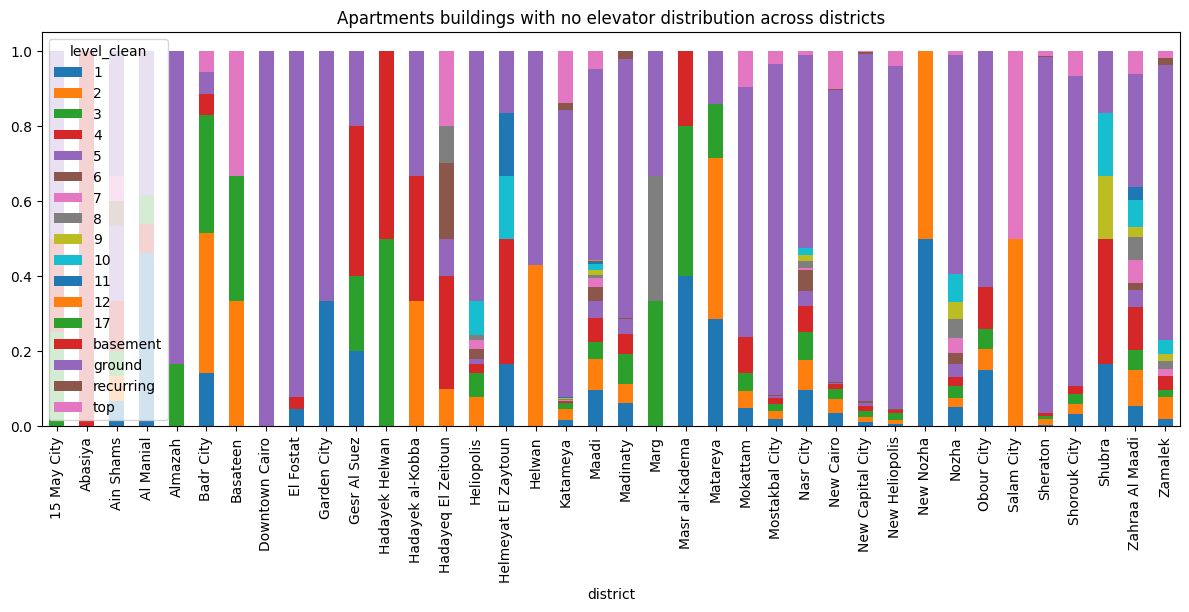

In [231]:
plot_df = data.unstack(level='level_clean').fillna(0)
plot_df = plot_df.loc[(plot_df !=0 ).any(axis=1), (plot_df !=0).any(axis=0)]
plot_df.plot(kind='bar', stacked=True, figsize=(12,6))
plt.tight_layout()
plt.title('Apartments buildings with no elevator distribution across districts')
plt.show()